# Model(CNN)

In [77]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WindowDetector(nn.Module):
    def __init__(self):
        super(WindowDetector, self).__init__()

        # Feature extraction
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # Pass a dummy tensor through conv layers to get the output size dynamically
        dummy_input = torch.rand(1, 3, 128, 128)
        with torch.no_grad():
            dummy_output = self.forward_features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        self.fc1 = nn.Linear(flattened_size, 256) # Flattened input size depends on image size
        self.fc2 = nn.Linear(256, 128)

        # Classification head (window vs. no window)
        self.classifier = nn.Linear(128, 2) # 2 classes: background or window

        self.bbox_regressor = nn.Linear(128, 4) # Output: [x, y, width, height]

    def forward_features(self, x):
        """Pass input through convolutional layers only"""
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = x.view(x.size(0), -1) # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        class_output = self.classifier(x) # classification output
        bbox_output = self.bbox_regressor(x) # Bounding box coordinates

        return class_output, bbox_output # Return both outputs
    
model = WindowDetector()
print(model)

WindowDetector(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
  (bbox_regressor): Linear(in_features=128, out_features=4, bias=True)
)


In [78]:
import os
import locale

os.environ["PYTHONUTF8"] = "1"  # Ensure UTF-8 is used
locale.setlocale(locale.LC_ALL, "sv_SE.UTF-8")  # Set Swedish locale)

'sv_SE.UTF-8'

# Pytorch dataset

In [79]:
import os
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class Blueprintdataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform
        self.images = [f for f in os.listdir(image_dir) if f.endswith(".png")]
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, index):
        img_name = self.images[index]
        img_path = os.path.join(self.image_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".png", ".txt"))

        # Load image 
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Load label
        with open(label_path, "r") as f:
            line = f.readline().strip().split()
            label = int(line[0])
            bbox = list(map(float, line[1:]))

        return image, torch.tensor(label, dtype=torch.long), torch.tensor(bbox, dtype=torch.float32)

transform = transforms.Compose([
     transforms.Resize((128, 128)),
     transforms.ToTensor()
])

dataset = Blueprintdataset("yolov5/datasets/images/train", "yolov5/datasets/labels/train", transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

# Define loss function and optimizer

In [80]:
import torch.optim as optim 

classification_loss_fn = nn.CrossEntropyLoss()
bbox_loss_fn = nn.L1Loss()

# Optimizer 
optimizer = optim.AdamW(model.parameters(), lr=0.0003, weight_decay=0.02)

# Training loop(CNN)

In [74]:
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def train(model, dataloader, optimizer, device):
    model.train()
    total_class_loss = 0
    total_bbox_loss = 0

    for images, labels, bboxes in dataloader:
        images.to(device)
        labels.to(device)
        bboxes.to(device)

        optimizer.zero_grad()

        class_preds, bbox_preds = model(images)

        # Compute class and bbox loss
        class_loss = classification_loss_fn(class_preds, labels)
        bbox_loss = bbox_loss_fn(bbox_preds, bboxes)

        loss = class_loss + bbox_loss # Combine both losses
        loss.backward()
        optimizer.step()

        total_class_loss += class_loss.item()
        total_bbox_loss += bbox_loss.item()

    return total_class_loss / len(dataloader), total_bbox_loss / len(dataloader)

num_epochs = 10
for epoch in range(num_epochs):
    class_loss, bbox_loss = train(model, dataloader, optimizer, device)
    print(f"Epoch {epoch+1}: Class Loss={class_loss:.4f}, BBox Loss={bbox_loss:.4f}")

    training_log = []

    training_log.append({
        'epoch': epoch + 1,
        'class_loss': class_loss,
        'bbox_loss': bbox_loss,
        'learning_rate': optimizer.param_groups[0]['lr']
    })

df = pd.DataFrame(training_log)

df.to_csv('training_log.csv', index=False)

print("Training log saved to training_log.csv")

Epoch 1: Class Loss=0.6589, BBox Loss=0.1911
Epoch 2: Class Loss=0.5693, BBox Loss=0.1788
Epoch 3: Class Loss=0.3947, BBox Loss=0.1516
Epoch 4: Class Loss=0.1698, BBox Loss=0.1234
Epoch 5: Class Loss=0.0338, BBox Loss=0.1266
Epoch 6: Class Loss=0.0050, BBox Loss=0.1205
Epoch 7: Class Loss=0.0012, BBox Loss=0.1221
Epoch 8: Class Loss=0.0004, BBox Loss=0.1451
Epoch 9: Class Loss=0.0002, BBox Loss=0.1283
Epoch 10: Class Loss=0.0001, BBox Loss=0.1370
Training log saved to training_log.csv


# Training loop(HPO)

In [ ]:
import optuna
import torch.optim as optim

# Define the objective function for Optuna
def objective(trial):
    # define search space for params
    lr = trial.suggest_loguniform("learning rate", 1e-5, 1e-2) # Log scale for better tuning
    batch_size = trial.suggest_categorical("Batch size", [4, 8, 16, 32])
    optimizer_name =  trial.suggest_categorical("optimizer", ["Adam", "SGD", "AdamW"])

    model = WindowDetector()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Select optimizer based on the search results
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters, lr=lr, momentum=0.9)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(10):
        total_loss = 0
        for batch in train_loader:
            images, labels = batch[:2]
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs[0], labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    # Validation loss 
    return total_loss / len(train_loader)

# optuna optimization
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

# Best hyperparams
print("Best hyperparameters:", study.best_params)

# Save best params to csv
df = pd.DataFrame([study.best_params])
df.to_csv("best_hyperparams.csv", index=False)


[I 2025-03-12 11:56:55,340] A new study created in memory with name: no-name-dd578ad9-666d-48eb-90b4-9cfeb42d066c
C:\Users\MaxF�rsntr�m-AI23GBG\AppData\Local\Temp\ipykernel_2904\1981974189.py:7: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("learning rate", 1e-5, 1e-2) # Log scale for better tuning
[W 2025-03-12 11:56:56,309] Trial 0 failed with parameters: {'learning rate': 1.0502849127352467e-05, 'Batch size': 16, 'optimizer': 'Adam'} because of the following error: TypeError("cross_entropy_loss(): argument 'input' (position 1) must be Tensor, not tuple").
Traceback (most recent call last):
  File "c:\Users\MaxF�rsntr�m-AI23GBG\LIA_2_blueprint_auto\Auto-Blueprints\.venv\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^

TypeError: cross_entropy_loss(): argument 'input' (position 1) must be Tensor, not tuple

# Evaluate

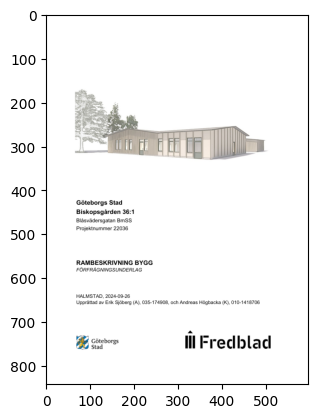

In [75]:
import matplotlib.pyplot as plt

def predict(model, image_path, device):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        class_preds, bbox_preds = model(image_tensor)

    class_idx = class_preds.argmax(dim=1).item()
    bbox = bbox_preds.cpu().numpy()[0]

    # Plot image with predicted bounding boxes
    plt.imshow(image)
    if class_idx == 1: # in case window is detected
        x, y, w, h = bbox
        x_min, y_min = x - w / 2, y - h / 2
        rect = plt.Rectangle((x_min * image.width, y_min * image.height), w * image.width, h * image.height,
                             fill=False, color="red", linewidth=2)
        plt.gca().add_patch(rect)
    plt.show()

predict(model, "yolov5/datasets/Blåsväder4_0.png", device)

# Correlation matrix

c:\Users\MaxF�rsntr�m-AI23GBG\LIA_2_blueprint_auto\Auto-Blueprints\.venv\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\MaxF�rsntr�m-AI23GBG\LIA_2_blueprint_auto\Auto-Blueprints\.venv\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


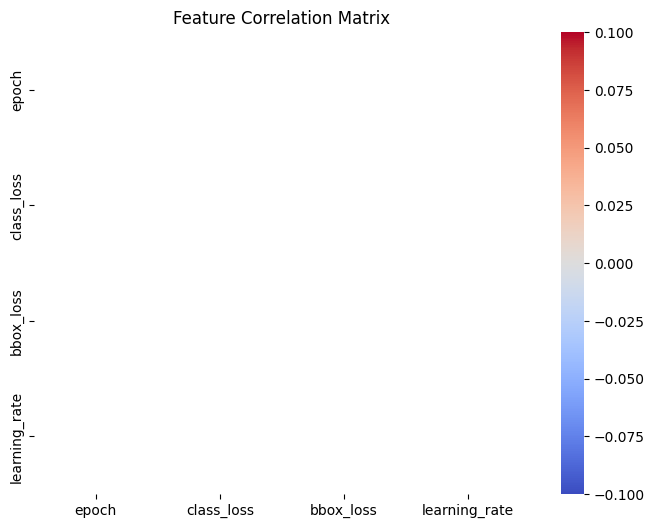

In [76]:
import pandas as pd
import seaborn as sns

# Load dataset (assuming a CSV with bounding box coordinates & other features)
df = pd.read_csv("training_log.csv")

# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()